# Minimal BEBM MLP Spectra Diagnostics

This notebook looks at the three learned matrices of the BEBM MLP energy:

- $W_1 =$ `net.0.weight`: visible pixels $\to$ hidden layer 1, shape `(512, 784)`.
- $W_2 =$ `net.2.weight`: hidden layer 1 $\to$ hidden layer 2, shape `(512, 512)`.
- $W_3 =$ `net.4.weight`: hidden layer 2 $\to$ scalar energy, shape `(1, 512)`.

Only $W_2$ is square, so only $W_2$ has ordinary eigenvalues. For all three matrices, we plot singular values, which are the right comparable spectra for rectangular and square matrices.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from rbms.io import load_model
from rbms.utils import get_saved_updates

device = "cpu"
dtype = torch.float32

filename = "pcd_trains/BEBM_MNIST_field_h512_ch1024_steps1000_lr1e-3.h5"
saved_updates = get_saved_updates(filename)

print(saved_updates)

/Users/aidan/Documents/Research_Internship/Code/rbms/rbms/dataset/dataset_class.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


[    1    51   101   151   201   251   301   351   401   451   501   551
   601   651   701   751   801   851   901   951  1001  1052  1102  1152
  1202  1252  1302  1352  1402  1452  1502  1552  1602  1652  1702  1752
  1802  1852  1902  1952  2002  2053  2103  2153  2203  2253  2303  2353
  2403  2453  2503  2553  2603  2653  2703  2753  2803  2853  2903  2953
  3003  3053  3104  3154  3204  3254  3304  3354  3404  3454  3504  3554
  3604  3654  3704  3754  3804  3854  3904  3954  4004  4054  4105  4155
  4205  4255  4305  4355  4405  4455  4505  4555  4605  4655  4705  4755
  4805  4855  4905  4955  5005  5055  5106  5156  5206  5256  5306  5356
  5406  5456  5506  5556  5606  5656  5706  5756  5806  5856  5906  5956
  6006  6056  6106  6157  6207  6257  6307  6357  6407  6457  6507  6557
  6607  6657  6707  6757  6807  6857  6907  6957  7007  7057  7107  7158
  7208  7258  7308  7358  7408  7458  7508  7558  7608  7658  7708  7758
  7808  7858  7908  7958  8008  8058  8108  8158  8

In [2]:
TOP_K = 10

matrix_names = {
    "W1": r"$W_1$ = net.0.weight, visible $\to$ hidden 1",
    "W2": r"$W_2$ = net.2.weight, hidden 1 $\to$ hidden 2",
    "W3": r"$W_3$ = net.4.weight, hidden 2 $\to$ energy",
}

top_singular_values = {name: [] for name in matrix_names}
top_w2_eigenvalue_abs = []

for update in saved_updates:
    params, _, _ = load_model(
        filename=filename,
        index=int(update),
        device=device,
        dtype=dtype,
    )

    W = {
        "W1": params.energy.net[0].weight.detach().cpu(),
        "W2": params.energy.net[2].weight.detach().cpu(),
        "W3": params.energy.net[4].weight.detach().cpu(),
    }

    for name, matrix in W.items():
        singular_values = torch.linalg.svdvals(matrix)
        top_singular_values[name].append(singular_values[:TOP_K].numpy())

    eigenvalues_w2 = torch.linalg.eigvals(W["W2"])
    eigenvalue_abs = torch.sort(eigenvalues_w2.abs(), descending=True).values
    top_w2_eigenvalue_abs.append(eigenvalue_abs[:TOP_K].numpy())

top_singular_values = {
    name: np.stack(values, axis=0)
    for name, values in top_singular_values.items()
}
top_w2_eigenvalue_abs = np.stack(top_w2_eigenvalue_abs, axis=0)

## Diagnostic 1: Top Singular Values During Training

This compares the effective strength/rank structure of the three learned matrices across saved checkpoints.

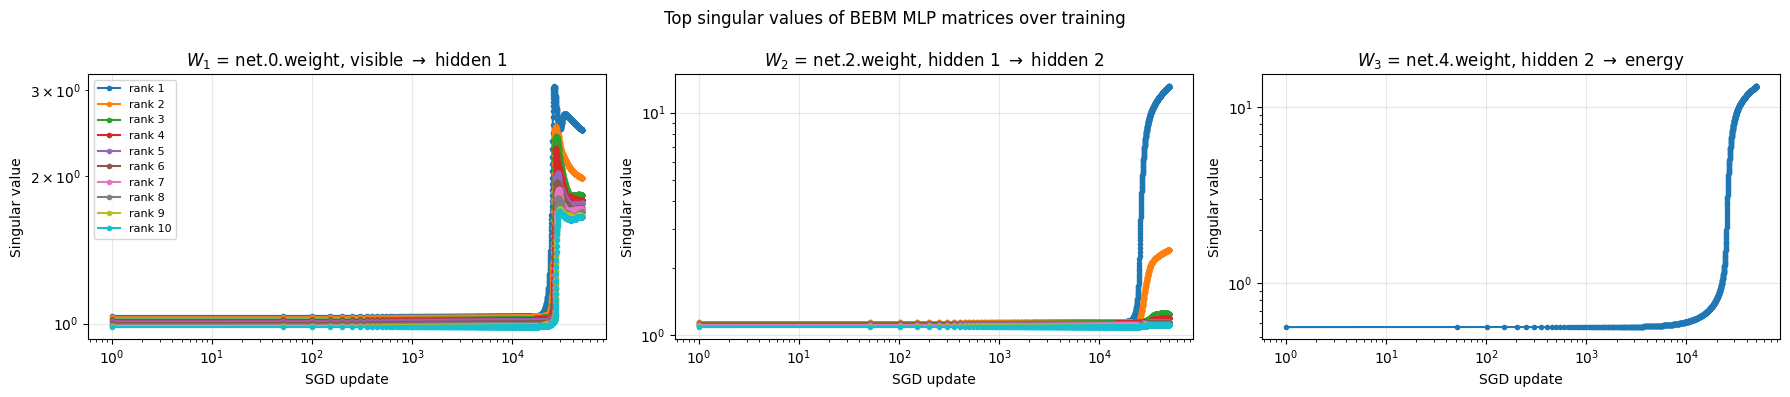

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, name in zip(axes, ["W1", "W2", "W3"]):
    values = top_singular_values[name]

    for rank in range(values.shape[1]):
        ax.plot(
            saved_updates,
            values[:, rank],
            marker="o",
            markersize=3,
            label=f"rank {rank + 1}",
        )

    ax.set_title(matrix_names[name])
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel("SGD update")
    ax.set_ylabel("Singular value")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle("Top singular values of BEBM MLP matrices over training")
plt.tight_layout()
plt.show()

## Diagnostic 2: True Eigenvalues of $W_2$ During Training

$W_2$ is the only square matrix. This plot follows the largest magnitudes of its ordinary eigenvalues.

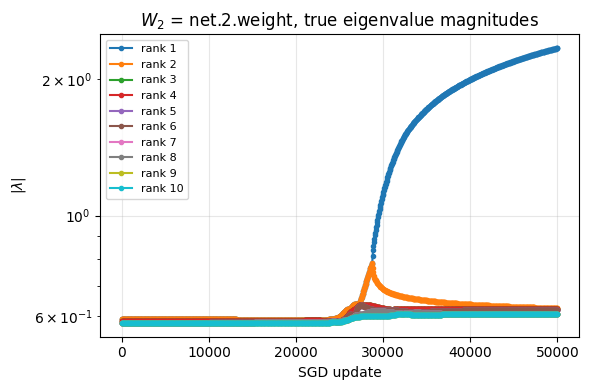

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

for rank in range(top_w2_eigenvalue_abs.shape[1]):
    ax.plot(
        saved_updates,
        top_w2_eigenvalue_abs[:, rank],
        marker="o",
        markersize=3,
        label=f"rank {rank + 1}",
    )

ax.set_title(r"$W_2$ = net.2.weight, true eigenvalue magnitudes")
ax.set_xlabel("SGD update")
ax.set_ylabel(r"$|\lambda|$")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()